In [ ]:
!pip install pm4py --upgrade

 Step 1: Exploring the Log File

In [ ]:
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.statistics.traces.generic.log import case_statistics
from pm4py.statistics.start_activities.log import get as start_activities
from pm4py.statistics.end_activities.log import get as end_activities

# Load the log file
log = xes_importer.apply('/content/drive/MyDrive/Fine_Management.xes')

# Number of cases
print("Number of cases:", len(log))

# Print attributes of the first case
print("\nFirst case attributes:")
print(log[0].attributes)

# Print events in the first case
print("\nEvents in the first case:")
for event in log[0]:
    print(event)

# Start activities
print("\nStart activities:")
print(start_activities.get_start_activities(log))

# End activities
print("\nEnd activities:")
print(end_activities.get_end_activities(log))

# Most frequent variants
print("\nMost frequent variants:")
variants_count = case_statistics.get_variant_statistics(log)
variants_count = sorted(variants_count, key=lambda x: x['count'], reverse=True)
for variant in variants_count[:5]:  # show top 5 variants
    print(variant)


parsing log, completed traces ::   0%|          | 0/150370 [00:00<?, ?it/s]

Number of cases: 150370

First case attributes:
{'concept:name': 'A1'}

Events in the first case:
{'amount': 35.0, 'org:resource': '561', 'dismissal': 'NIL', 'concept:name': 'Create Fine', 'vehicleClass': 'A', 'totalPaymentAmount': 0.0, 'lifecycle:transition': 'complete', 'time:timestamp': datetime.datetime(2006, 7, 24, 0, 0), 'article': 157, 'points': 0}
{'concept:name': 'Send Fine', 'lifecycle:transition': 'complete', 'expense': 11.0, 'time:timestamp': datetime.datetime(2006, 12, 5, 0, 0)}

Start activities:
{'Create Fine': 150370}

End activities:
{'Send Fine': 20755, 'Send for Credit Collection': 58997, 'Payment': 67201, 'Send Appeal to Prefecture': 3144, 'Appeal to Judge': 134, 'Notify Result Appeal to Offender': 86, 'Receive Result Appeal from Prefecture': 53}

Most frequent variants:
{'variant': ('Create Fine', 'Send Fine', 'Insert Fine Notification', 'Add penalty', 'Send for Credit Collection'), 'count': 56482}
{'variant': ('Create Fine', 'Payment'), 'count': 46371}
{'variant':

# 2. Preprocessing and Feature Engineering
Load Event Log and Preprocess

In [ ]:
from pm4py.algo.filtering.log.attributes import attributes_filter
from pm4py.algo.filtering.log.start_activities import start_activities_filter
from pm4py.algo.filtering.log.end_activities import end_activities_filter
from pm4py.objects.conversion.log import converter as log_converter

import pandas as pd

# Convert to DataFrame
df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

In [ ]:
df.head()

,amount,org:resource,dismissal,concept:name,vehicleClass,totalPaymentAmount,lifecycle:transition,time:timestamp,article,points,case:concept:name,expense,notificationType,lastSent,paymentAmount,matricola
0,35.0,561,NIL,Create Fine,A,0.0,complete,2006-07-24,157.0,0.0,A1,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,Send Fine,NaN,NaN,complete,2006-12-05,NaN,NaN,A1,11.0,NaN,NaN,NaN,NaN
2,35.0,561,NIL,Create Fine,A,0.0,complete,2006-08-02,157.0,0.0,A100,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Send Fine,NaN,NaN,complete,2006-12-12,NaN,NaN,A100,11.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Insert Fine Notification,NaN,NaN,complete,2007-01-15,NaN,NaN,A100,NaN,P,P,NaN,NaN


Aggregate Events to Case-Level

In [ ]:
# Sort by timestamp
df = df.sort_values('time:timestamp')

# Group by case
grouped = df.groupby('case:concept:name')

# Feature engineering
cases_df = grouped.agg({
    'concept:name': lambda x: list(x),  # event sequence
    'time:timestamp': [min, max],
    'amount': 'sum',
    'points': 'sum',
    'totalPaymentAmount': 'sum',
    'org:resource': lambda x: x.nunique(),
})

# Flatten multi-index columns
cases_df.columns = ['_'.join(col).strip() for col in cases_df.columns.values]
cases_df = cases_df.reset_index()

# Add duration in days
cases_df['duration_days'] = (cases_df['time:timestamp_max'] - cases_df['time:timestamp_min']).dt.days

# Add target variable (e.g., last event in the sequence)
cases_df['target'] = cases_df['concept:name_<lambda>'].apply(lambda x: x[-1])


/usr/local/lib/python3.11/dist-packages/cudf/pandas/fast_slow_proxy.py:28: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cudf/pandas/fast_slow_proxy.py:28: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  return fn(*args, **kwargs)


# 3. Apply Random Forest for Prediction
Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Encode categorical target
cases_df['target'] = cases_df['target'].astype('category').cat.codes

# Select features
X = cases_df[['amount_sum', 'points_sum', 'totalPaymentAmount_sum', 'org:resource_<lambda>', 'duration_days']]
y = cases_df['target']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Random Forest

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.21      0.12      0.15       101
           1       0.92      0.92      0.92        25
           2       0.52      0.41      0.46       480
           3       0.17      0.14      0.15        14
           4       0.97      0.98      0.97     12819
           5       0.14      0.08      0.11        12
           6       0.90      0.86      0.88       636
           7       0.98      0.98      0.98      4155
           8       1.00      1.00      1.00     11832

    accuracy                           0.97     30074
   macro avg       0.65      0.61      0.62     30074
weighted avg       0.97      0.97      0.97     30074



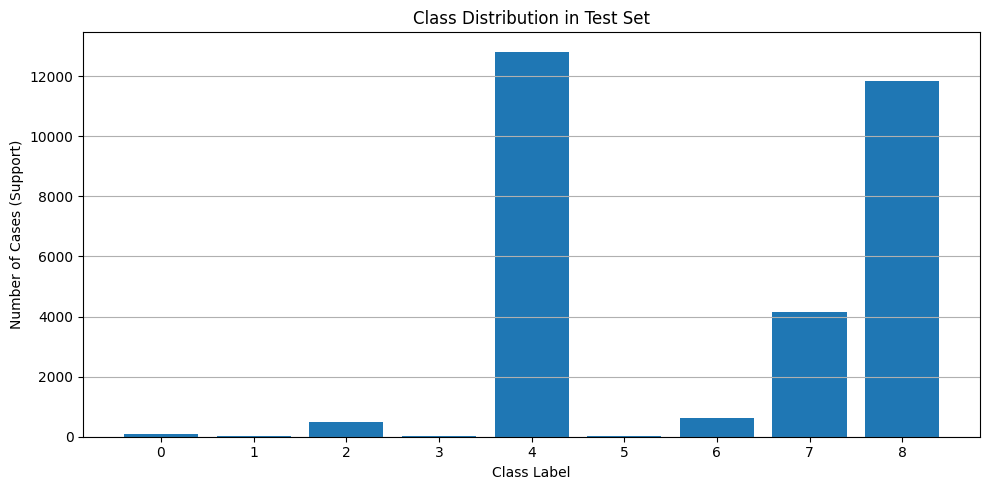

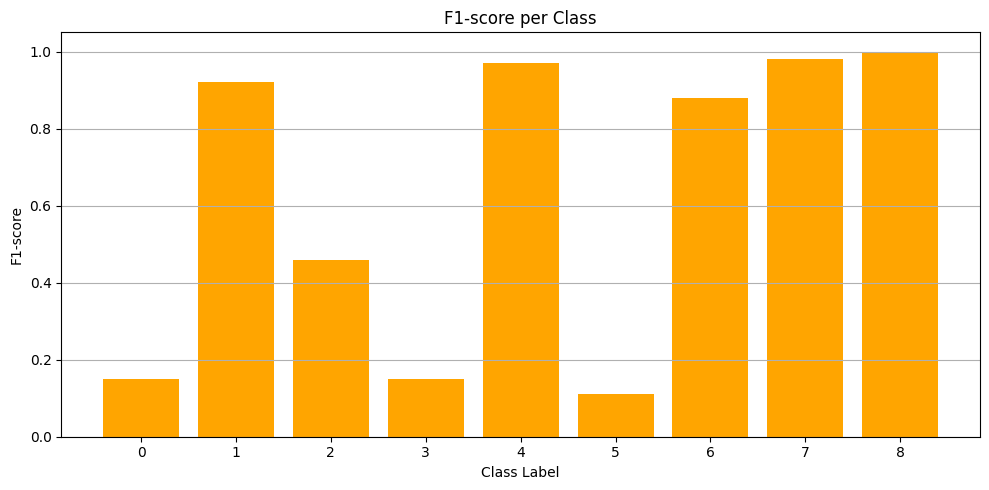

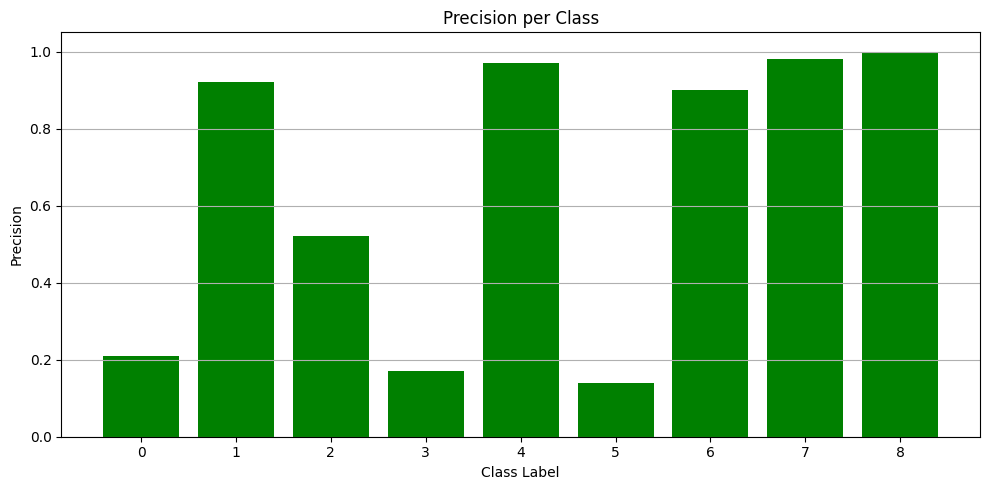

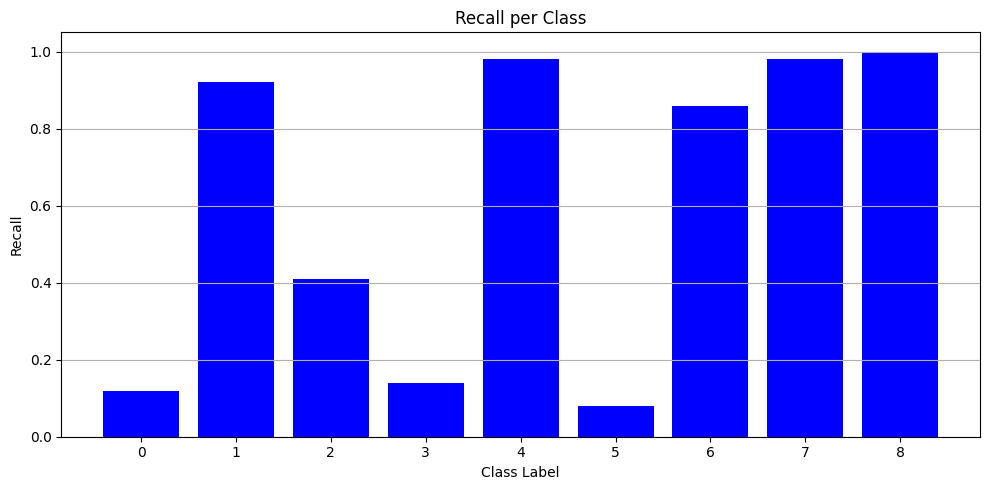

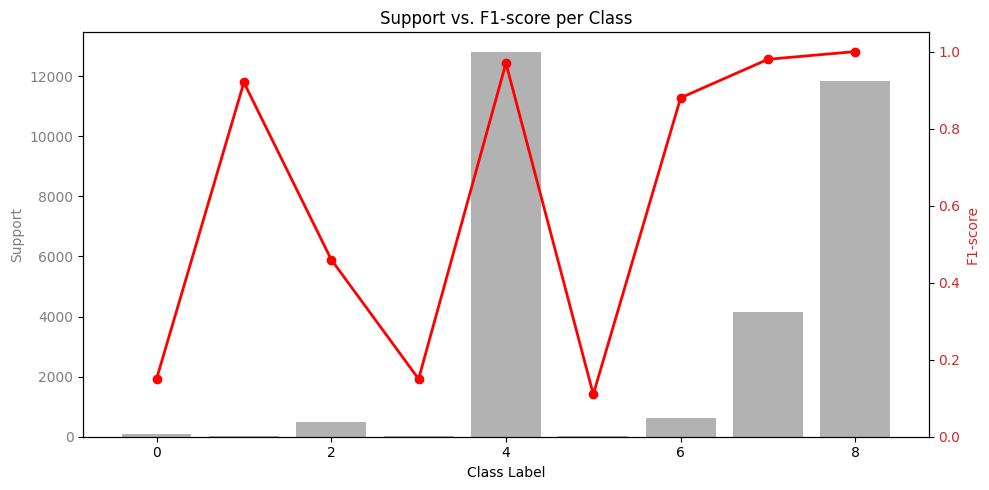

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Replace these with your actual metrics from the classification report
class_labels = list(range(9))
support = [101, 25, 480, 14, 12819, 12, 636, 4155, 11832]
precision = [0.21, 0.92, 0.52, 0.17, 0.97, 0.14, 0.90, 0.98, 1.00]
recall =    [0.12, 0.92, 0.41, 0.14, 0.98, 0.08, 0.86, 0.98, 1.00]
f1_score =  [0.15, 0.92, 0.46, 0.15, 0.97, 0.11, 0.88, 0.98, 1.00]

# Create a DataFrame
df = pd.DataFrame({
    'Class': class_labels,
    'Support': support,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})

# Chart 1: Class distribution
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['Support'])
plt.xlabel('Class Label')
plt.ylabel('Number of Cases (Support)')
plt.title('Class Distribution in Test Set')
plt.xticks(df['Class'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Chart 2: F1-score per class
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['F1-score'], color='orange')
plt.xlabel('Class Label')
plt.ylabel('F1-score')
plt.title('F1-score per Class')
plt.xticks(df['Class'])
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Chart 3: Precision per class
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['Precision'], color='green')
plt.xlabel('Class Label')
plt.ylabel('Precision')
plt.title('Precision per Class')
plt.xticks(df['Class'])
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Chart 4: Recall per class
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['Recall'], color='blue')
plt.xlabel('Class Label')
plt.ylabel('Recall')
plt.title('Recall per Class')
plt.xticks(df['Class'])
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Chart 5: Support vs. F1-score overlay
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Class Label')
ax1.set_ylabel('Support', color='tab:gray')
ax1.bar(df['Class'], df['Support'], alpha=0.6, color='gray', label='Support')
ax1.tick_params(axis='y', labelcolor='tab:gray')

ax2 = ax1.twinx()
ax2.set_ylabel('F1-score', color='tab:red')
ax2.plot(df['Class'], df['F1-score'], color='red', marker='o', linewidth=2, label='F1-score')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 1.05)

plt.title('Support vs. F1-score per Class')
fig.tight_layout()
plt.show()


Class Weights (Low-effort Fix)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train with balanced class weights
model_classWeight = RandomForestClassifier(class_weight='balanced', random_state=42)
model_classWeight.fit(X_train, y_train)

# Predict and evaluate
y_pred = model_classWeight.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.20      0.27      0.23       101
           1       0.91      0.84      0.88        25
           2       0.50      0.99      0.67       480
           3       0.12      0.14      0.13        14
           4       0.99      0.95      0.97     12819
           5       0.00      0.00      0.00        12
           6       0.83      0.85      0.84       636
           7       0.98      0.98      0.98      4155
           8       1.00      1.00      1.00     11832

    accuracy                           0.97     30074
   macro avg       0.61      0.67      0.63     30074
weighted avg       0.98      0.97      0.97     30074



SMOTE Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train Random Forest on balanced data
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_resampled, y_resampled)

# Predict and evaluate
y_pred = model_smote.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.18      0.43      0.26       101
           1       0.78      0.84      0.81        25
           2       0.50      0.99      0.66       480
           3       0.04      0.21      0.07        14
           4       0.99      0.94      0.97     12819
           5       0.04      0.17      0.06        12
           6       0.71      0.78      0.75       636
           7       0.98      0.97      0.97      4155
           8       1.00      0.99      0.99     11832

    accuracy                           0.96     30074
   macro avg       0.58      0.70      0.62     30074
weighted avg       0.97      0.96      0.97     30074



Hybrid Approach

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

model_hybrid = RandomForestClassifier(random_state=42)
model_hybrid = RandomForestClassifier(class_weight='balanced', random_state=42)
model_hybrid.fit(X_resampled, y_resampled)

# Predict and evaluate
y_pred = model_hybrid.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.18      0.43      0.26       101
           1       0.78      0.84      0.81        25
           2       0.50      0.99      0.66       480
           3       0.04      0.21      0.07        14
           4       0.99      0.94      0.97     12819
           5       0.04      0.17      0.06        12
           6       0.71      0.78      0.75       636
           7       0.98      0.97      0.97      4155
           8       1.00      0.99      0.99     11832

    accuracy                           0.96     30074
   macro avg       0.58      0.70      0.62     30074
weighted avg       0.97      0.96      0.97     30074



Feature Importance Plot

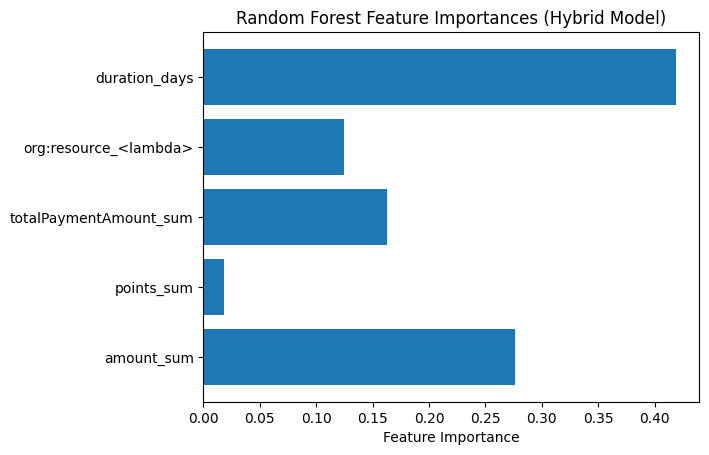

In [ ]:
import matplotlib.pyplot as plt

importances = model_hybrid.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (Hybrid Model)")
plt.show()


Evaluate Confusion Matrix

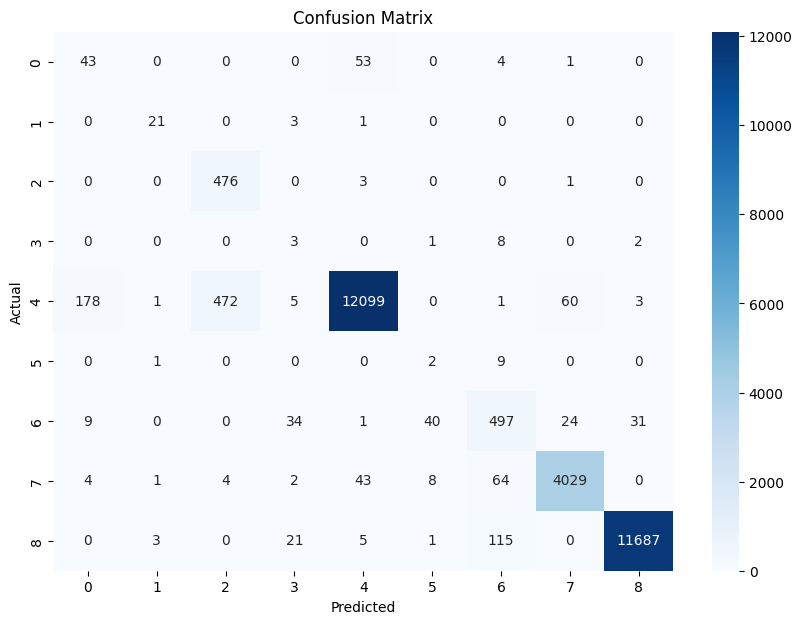

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
